In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp
from oetils import init_plotting

In [2]:
W = init_plotting(latex=True, sans=True)

In [3]:
p0 = 0.101  # Gas absolute pressure [atm]
V0 = 2.50   # Gas volume [L]
T0 = 22.0   # Gas temperature [°C]
data = pd.DataFrame({
    'V': [2.50, 2.02, 1.48, 1.01, 0.50],  # Gas volume [L]
    'p': [0.101, 0.139, 0.202, 0.361, 0.952],  # Gas absolute pressure [atm]
})

# Convert to SI
p0 *= sp.constants.atm
V0 *= sp.constants.liter
T0 += sp.constants.zero_Celsius
data['V'] *= sp.constants.liter
data['p'] *= sp.constants.atm

data

,V,p
0,0.00250,10233.825
1,0.00202,14084.175
2,0.00148,20467.650
3,0.00101,36578.325
4,0.00050,96461.400


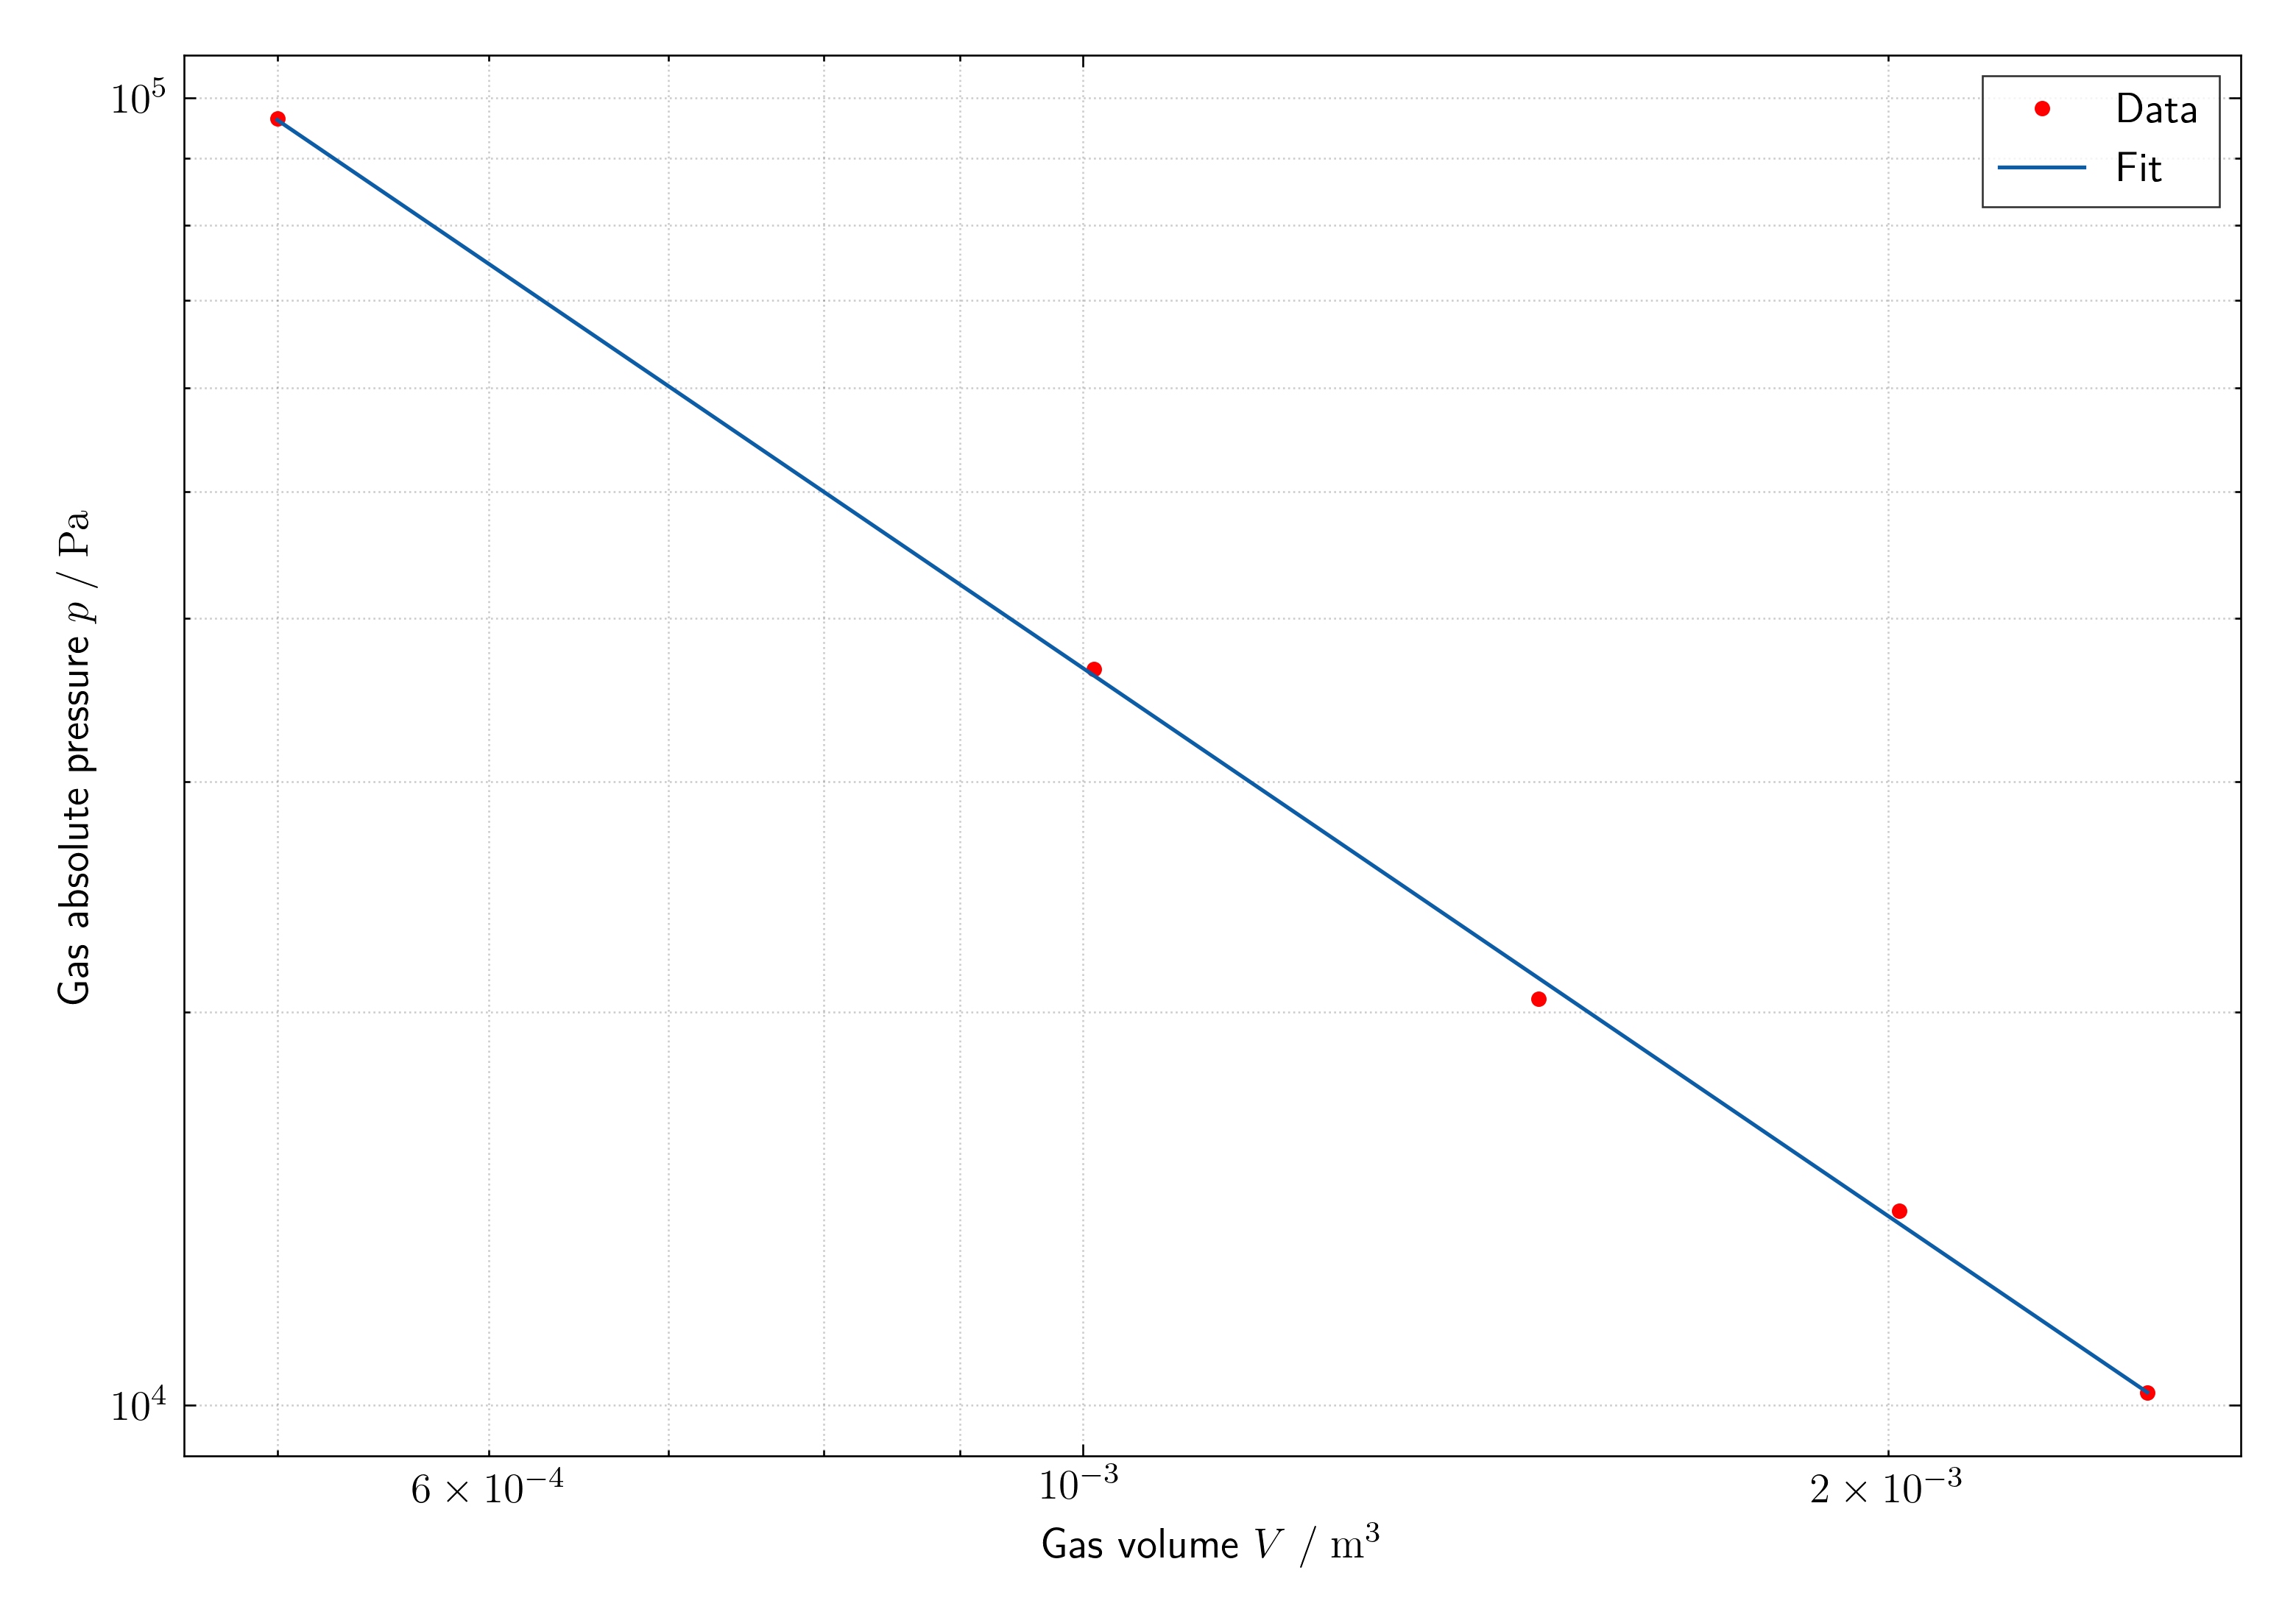

In [4]:
x = np.hstack([np.ones((len(data.V), 1)), np.log(data['V'].values[:, None])])
y = np.log(data['p'])
w = np.linalg.lstsq(x, y)[0]

# Plot
fig, ax = plt.subplots()
ax.set_xlabel(r"Gas volume $V\;/\;\mathrm{m^3}$")
ax.set_ylabel(r"Gas absolute pressure $p\;/\;\mathrm{Pa}$")
ax.set_xscale('log')
ax.set_yscale('log')
ax.plot(data['V'], data['p'], 'r.', label="Data")
x = np.linspace(data['V'].min(), data['V'].max())
ax.plot(x, np.exp(w[0] + w[1] * np.log(x)), label="Fit")
ax.grid(True, 'both')
ax.legend()
plt.show()

In [5]:
gam = -w[1]
print(f"The heat capacity ratio is gamma = {gam:.2f}, which is close to the theoretical value 1.40 of a diatomic gas.")

The heat capacity ratio is gamma = 1.39, which is close to the theoretical value 1.40 of a diatomic gas.


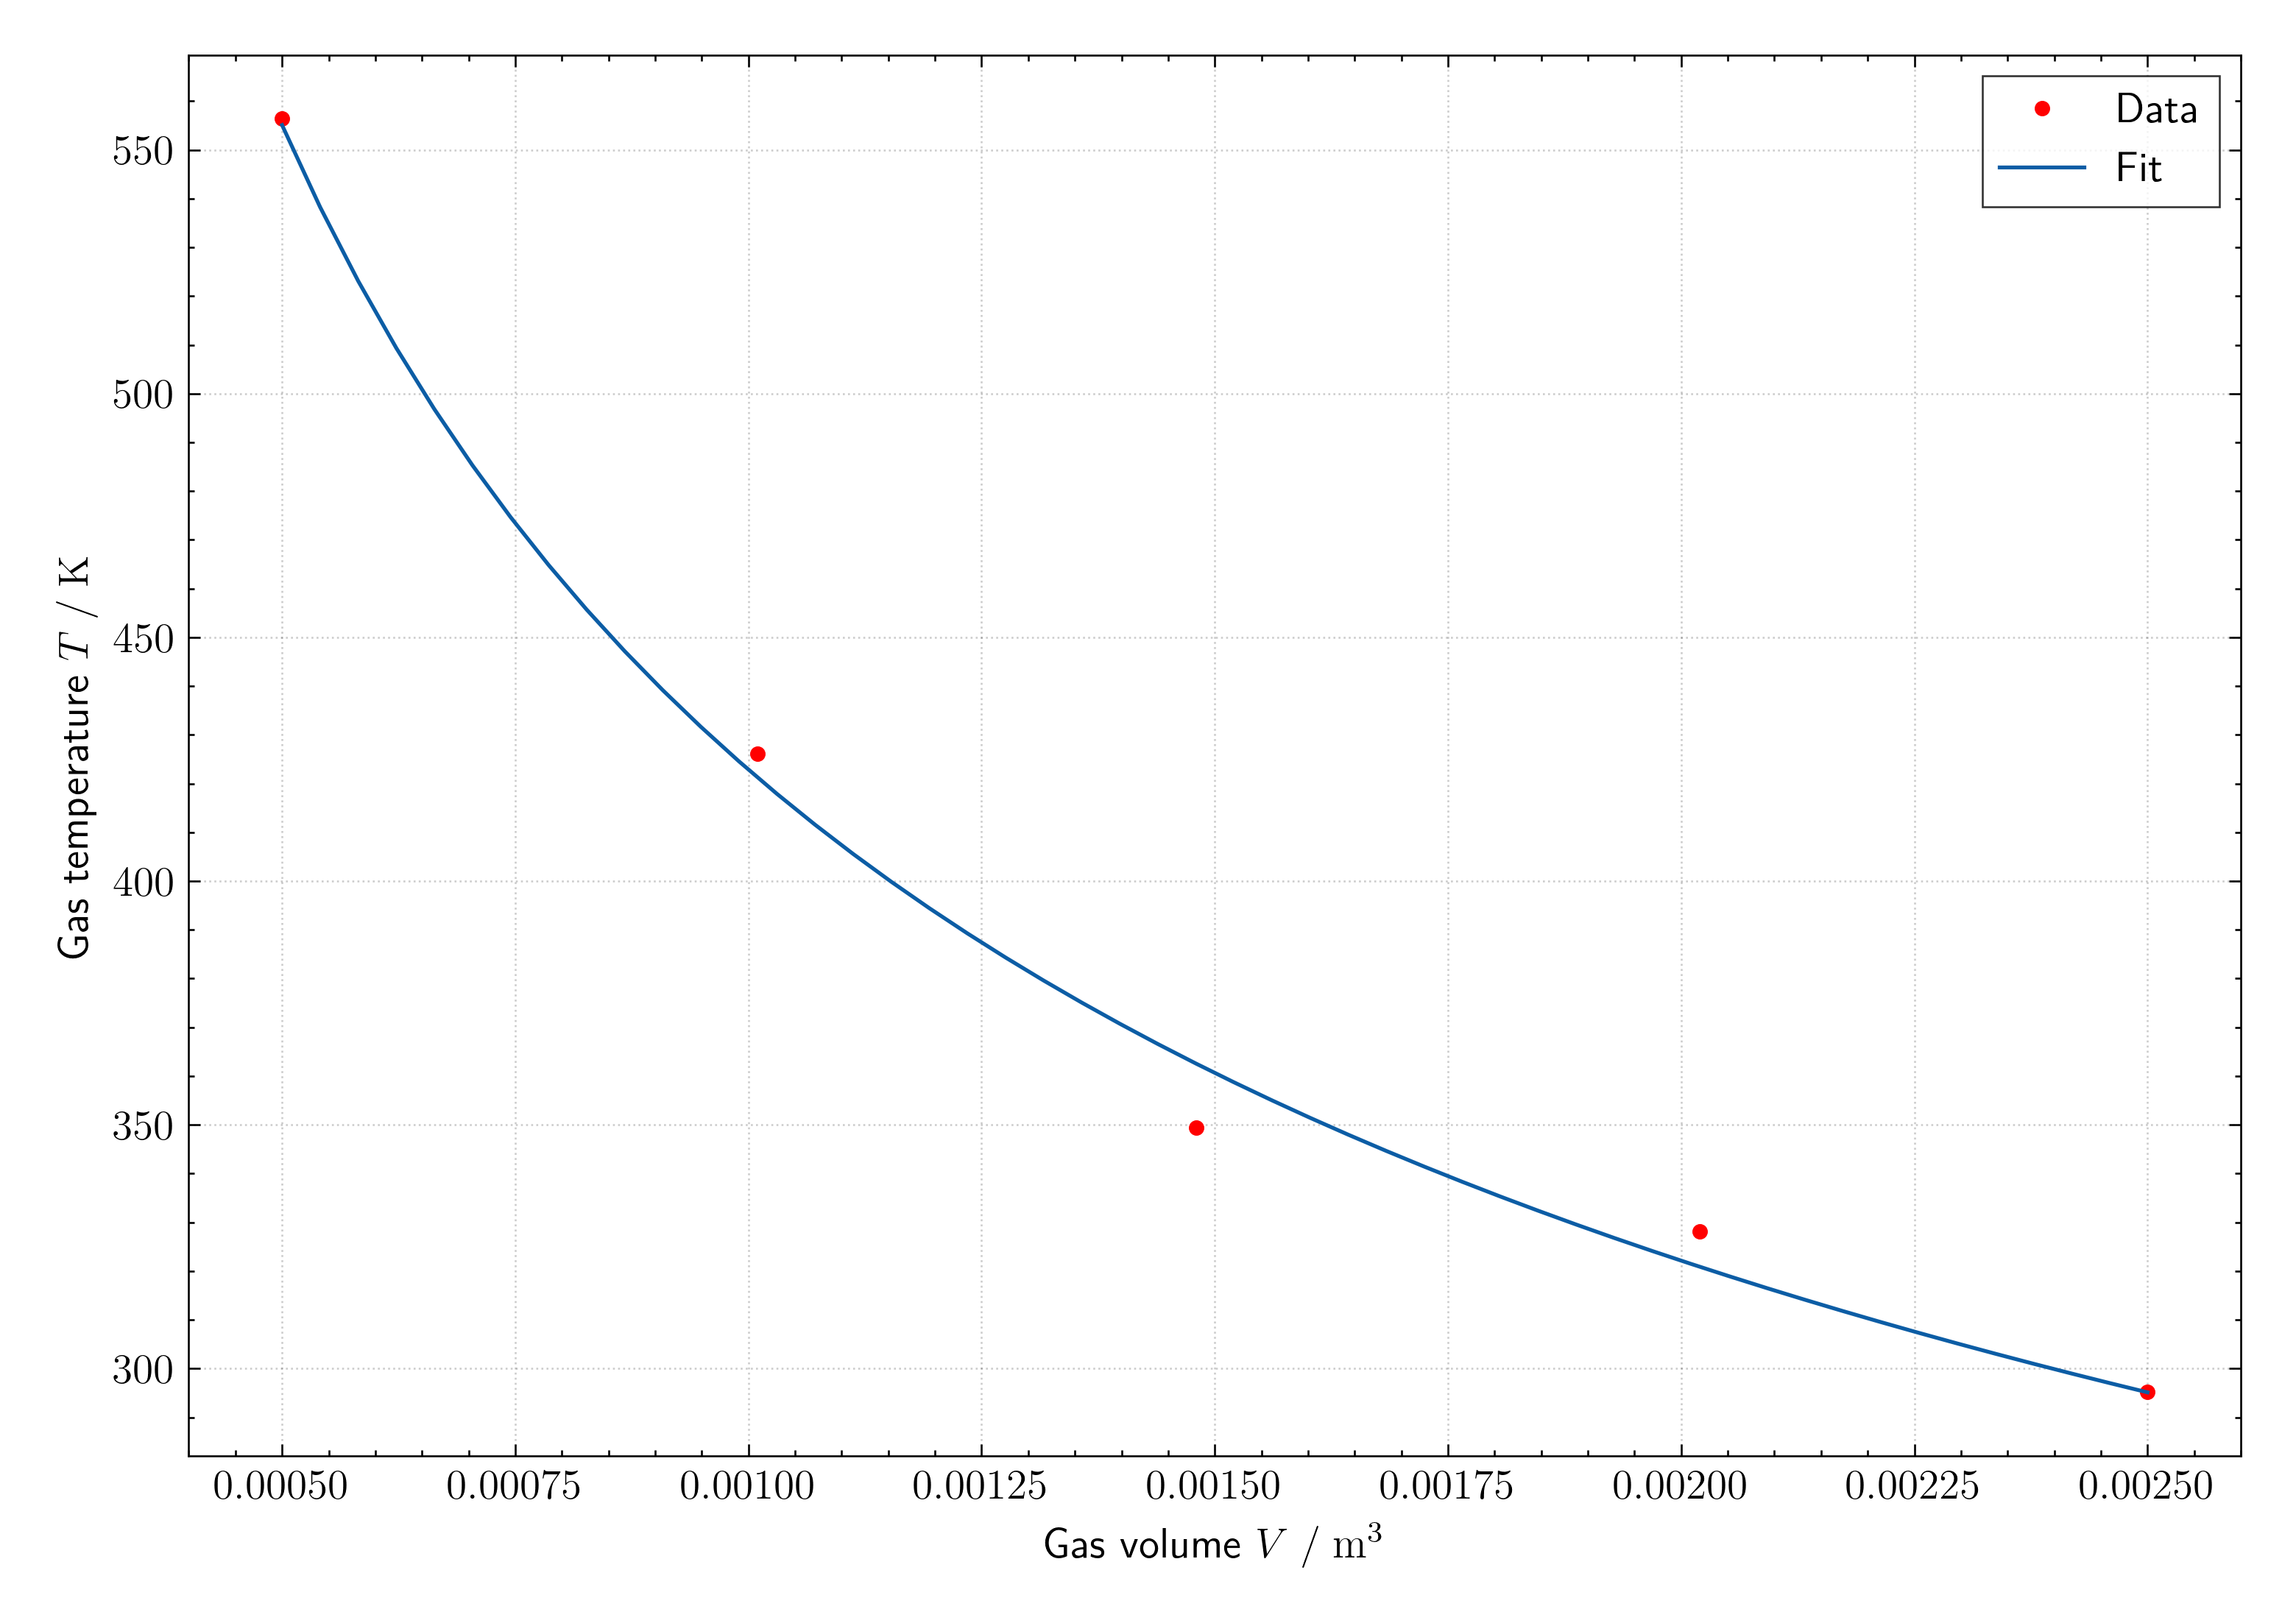

In [6]:
n = p0 * V0 / T0 / sp.constants.gas_constant
data['T'] = data.p * data.V / n / sp.constants.gas_constant
T = x * np.exp(w[0] + w[1] * np.log(x)) / n / sp.constants.gas_constant

# Plot
fig, ax = plt.subplots()
ax.set_xlabel(r"Gas volume $V\;/\;\mathrm{m^3}$")
ax.set_ylabel(r"Gas temperature $T\;/\;\mathrm{K}$")
ax.plot(data['V'], data['T'], 'r.', label="Data")
ax.plot(x, T, label="Fit")
ax.legend()
plt.show()